<a href="https://colab.research.google.com/github/malick08012/Loan-Approval-Prediction/blob/main/Loan_Approval_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

**Upload Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()



Saving LoanApprovalPrediction.csv to LoanApprovalPrediction.csv


**Load Dataset**

In [3]:
df = pd.read_csv("LoanApprovalPrediction.csv")

print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Check**

In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


**Handle Missing Values**

Fill Numerical Columns with Median

In [5]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_796/1384138331.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


Fill Categorical Columns with Mode

In [6]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_796/2213161713.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


**Check**

In [7]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


**Check Class Imbalance**

In [8]:
df['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


**Visualize**

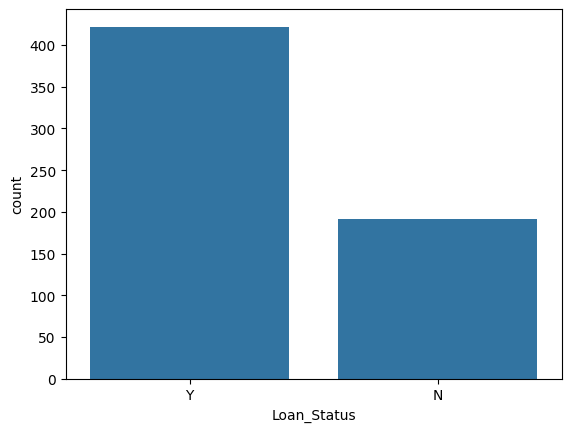

In [9]:
sns.countplot(x='Loan_Status', data=df)
plt.show()

**Encode Categorical Variables**

Convert Target Variable:

In [10]:
df['Loan_Status'] = df['Loan_Status'].map({'Y':1, 'N':0})

**One-Hot Encode Remaining Categorical Features**

In [11]:
df = pd.get_dummies(df, drop_first=True)

**Now check**

In [12]:
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Loan_ID_LP001003,Loan_ID_LP001005,Loan_ID_LP001006,Loan_ID_LP001008,...,Loan_ID_LP002990,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,1,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,0,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,1,False,True,False,False,...,False,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,1,False,False,True,False,...,False,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,1,False,False,False,True,...,False,True,False,False,False,False,False,False,False,True


**Define Features & Target**

In [13]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

**Train-Test Split**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Train Logistic Regression (Baseline Model)**

In [15]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Evaluate Logistic Regression**

In [16]:
print("Logistic Regression Report:\n")
print(classification_report(y_test, y_pred_log))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Report:

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123

Confusion Matrix:

[[18 25]
 [ 1 79]]


**Train Decision Tree (Comparison Model)**

In [17]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

**Evaluate Decision Tree**

In [18]:
print("Decision Tree Report:\n")
print(classification_report(y_test, y_pred_tree))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_tree))

Decision Tree Report:

              precision    recall  f1-score   support

           0       0.56      0.42      0.48        43
           1       0.73      0.82      0.77        80

    accuracy                           0.68       123
   macro avg       0.64      0.62      0.63       123
weighted avg       0.67      0.68      0.67       123

Confusion Matrix:

[[18 25]
 [14 66]]


**Install SMOTE**

Balance the training data using SMOTE

In [19]:
!pip install imbalanced-learn

**Apply SMOTE**

In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: Loan_Status
1    342
0    149
Name: count, dtype: int64
After SMOTE: Loan_Status
0    342
1    342
Name: count, dtype: int64


**Retrain Logistic Regression**

In [21]:
log_model_smote = LogisticRegression(max_iter=1000)
log_model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = log_model_smote.predict(X_test)

print("Logistic Regression with SMOTE:\n")
print(classification_report(y_test, y_pred_smote))
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_smote))

Logistic Regression with SMOTE:

              precision    recall  f1-score   support

           0       0.83      0.44      0.58        43
           1       0.76      0.95      0.84        80

    accuracy                           0.77       123
   macro avg       0.79      0.70      0.71       123
weighted avg       0.78      0.77      0.75       123

Confusion Matrix:

[[19 24]
 [ 4 76]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Add Feature Scaling ( Scale the Data )**

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

**Increase Iterations**

In [23]:
log_model_scaled = LogisticRegression(max_iter=5000)

log_model_scaled.fit(X_train_scaled, y_train_smote)

y_pred_scaled = log_model_scaled.predict(X_test_scaled)

print("Logistic Regression with SMOTE + Scaling:\n")
print(classification_report(y_test, y_pred_scaled))
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_scaled))

Logistic Regression with SMOTE + Scaling:

              precision    recall  f1-score   support

           0       0.83      0.44      0.58        43
           1       0.76      0.95      0.84        80

    accuracy                           0.77       123
   macro avg       0.79      0.70      0.71       123
weighted avg       0.78      0.77      0.75       123

Confusion Matrix:

[[19 24]
 [ 4 76]]


**Decision Tree + SMOTE**

In [24]:
from sklearn.tree import DecisionTreeClassifier

tree_smote = DecisionTreeClassifier(random_state=42)

tree_smote.fit(X_train_smote, y_train_smote)

y_pred_tree_smote = tree_smote.predict(X_test)

print("Decision Tree with SMOTE:\n")
print(classification_report(y_test, y_pred_tree_smote))
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_tree_smote))

Decision Tree with SMOTE:

              precision    recall  f1-score   support

           0       0.77      0.47      0.58        43
           1       0.76      0.93      0.84        80

    accuracy                           0.76       123
   macro avg       0.77      0.70      0.71       123
weighted avg       0.77      0.76      0.75       123

Confusion Matrix:

[[20 23]
 [ 6 74]]


📊 Final Model Comparison (All 4)

Model            Recall (Class 0)         F1 (Class 0)               Accuracy

Logistic                0.42                    0.58                   0.79

Decision Tree           0.42                    0.48                   0.68

Logistic + SMOTE        0.44                    0.58                   0.77

Decision Tree + SMOTE   0.47                   0.58                    0.76

**Final Conclusion**

This project developed and evaluated multiple classification models to predict loan approval decisions using applicant financial and demographic information. Logistic Regression achieved the highest overall accuracy (79%), while Decision Tree with SMOTE slightly improved detection of rejected applicants with a recall of 47%. Although SMOTE improved minority class performance, the models still struggled to accurately identify risky applicants. The results highlight the importance of handling imbalanced data and focusing on precision, recall, and F1-score rather than relying solely on accuracy. Further improvement could be achieved through advanced models and enhanced feature engineering.